#Project Title : Shoppers Spectrum

## Step 1 – Dataset Collection and Understanding

In this step I have loaded the public e-commerce dataset and do a quick
data audit: structure, missing values, duplicates and basic sanity
checks. This tells us what data quality issues we must fix later.


### 1.1 Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

import joblib

from IPython.display import display
sns.set(style="whitegrid")


In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 39.3 MB/s eta 0:00:00


In [ ]:
import streamlit as st

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# List top-level items in MyDrive
os.listdir('/content/drive/MyDrive/Labmentix_P2')

['online_retail.csv',
 'app.py',
 'Shoppers_Spectrum.ipynb',
 'rfm_kmeans_segment_model.pkl',
 'product_similarity_model.pkl']

### 1.2 Load the Dataset


In [ ]:
# Change the file name/path as per your local/Colab setup
file_path = "/content/drive/MyDrive/Labmentix_P2/online_retail.csv"   # e.g. the dataset you downloaded
df = pd.read_csv(file_path, encoding="latin1")

print("Shape:", df.shape)
df.head()


Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


### 1.3 Basic Info

In [ ]:
print("\nDataset shape (rows, columns):", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nInfo:")
df.info()


Dataset shape (rows, columns): (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### 1.4 Check missing values

In [ ]:
print("\n Missing values per column:")
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent.round(2)
})

display(missing_df.sort_values("missing_percent", ascending=False))



 Missing values per column:


,missing_count,missing_percent
CustomerID,135080,24.93
Description,1454,0.27
StockCode,0,0.00
InvoiceNo,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


### 1.5. Check duplicates

In [ ]:
print("\n Number of duplicate rows:", df.duplicated().sum())

# If you want to see a few duplicate rows:
dup_rows = df[df.duplicated()]
if not dup_rows.empty:
    print("\nSample duplicate rows:")
    display(dup_rows.head())
else:
    print("No exact duplicate rows found.")



 Number of duplicate rows: 5268

Sample duplicate rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2022-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2022-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2022-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2022-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2022-12-01 11:49:00,2.95,17920.0,United Kingdom


### 1.6 Basic data sanity checks (unusual records)

In [ ]:
print("\nTransactions with non-positive Quantity (<= 0):", (df["Quantity"] <= 0).sum())
print("Transactions with non-positive UnitPrice (<= 0):", (df["UnitPrice"] <= 0).sum())

print("\nRows with missing CustomerID:", df["CustomerID"].isna().sum())

print("\nInvoiceDate range:")
print("Min:", df["InvoiceDate"].min())
print("Max:", df["InvoiceDate"].max())

print("\nUnique countries:", df["Country"].nunique())
print(df["Country"].value_counts().head(10))



Transactions with non-positive Quantity (<= 0): 10624
Transactions with non-positive UnitPrice (<= 0): 2517

Rows with missing CustomerID: 135080

InvoiceDate range:
Min: 2022-12-01 08:26:00
Max: 2023-12-09 12:50:00

Unique countries: 38
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


## Step 2 – Data Cleaning & Feature Engineering

Here I have created a cleaned transactional dataset (df_clean) by:
- Dropping rows without CustomerID
- Excluding cancelled invoices (InvoiceNo starting with 'C')
- Removing rows with Quantity <= 0 or UnitPrice <= 0
- Converting InvoiceDate to datetime
- Creating TotalPrice = Quantity * UnitPrice

This ensures that only valid, completed purchases are used for
EDA, RFM analysis, clustering and recommendations.




In [ ]:
# Work on a copy to keep raw df intact
df_clean = df.copy()

print("Original shape:", df_clean.shape)


Original shape: (541909, 8)



### 2.1 Drop missing CustomerID

In [ ]:
# Drop missing CustomerID
missing_cust_before = df_clean["CustomerID"].isna().sum()
print("Rows with missing CustomerID (before):", missing_cust_before)

df_clean = df_clean.dropna(subset=["CustomerID"])
missing_cust_after = df_clean["CustomerID"].isna().sum()
print("Rows with missing CustomerID (after):", missing_cust_after)
print("Shape after dropping missing CustomerID:", df_clean.shape)

Rows with missing CustomerID (before): 135080
Rows with missing CustomerID (after): 0
Shape after dropping missing CustomerID: (406829, 8)


### 2.2 Remove cancelled invoices (InvoiceNo starting with 'C')

In [ ]:
# Exclude cancelled invoices (InvoiceNo starting with 'C')
#    (Cancelled invoices usually have InvoiceNo like 'C123456')
cancel_mask = df_clean["InvoiceNo"].astype(str).str.startswith("C")
cancel_count = cancel_mask.sum()
print("Cancelled invoices found:", cancel_count)

df_clean = df_clean[~cancel_mask].reset_index(drop=True)
print("Shape after removing cancelled invoices:", df_clean.shape)

Cancelled invoices found: 8905
Shape after removing cancelled invoices: (397924, 8)


### 2.3 Remove non-positive quantities/prices

In [ ]:

# Remove negative or zero quantities and prices
bad_qty = (df_clean["Quantity"] <= 0).sum()
bad_price = (df_clean["UnitPrice"] <= 0).sum()
print("Rows with Quantity <= 0:", bad_qty)
print("Rows with UnitPrice <= 0:", bad_price)

df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)].reset_index(drop=True)
print("Shape after removing bad Quantity/UnitPrice:", df_clean.shape)


Rows with Quantity <= 0: 0
Rows with UnitPrice <= 0: 40
Shape after removing bad Quantity/UnitPrice: (397884, 8)


### 2.4 Ensure datetime and create TotalPrice

In [ ]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

print("\nData preprocessing complete.")
display(df_clean.head())


Data preprocessing complete.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In the preprocessing step, I created a cleaned version of the dataset by removing rows with missing CustomerID, excluding cancelled invoices (identified by InvoiceNo starting with “C”), and filtering out transactions where Quantity or UnitPrice were less than or equal to zero. This ensures that only valid, completed purchases are used in downstream RFM analysis, clustering, and recommendation modelling.

## Step 3 – Exploratory Data Analysis (EDA)

### 3.1 Analyze transaction volume by country

Transaction volume by country (top 10):
Country
United Kingdom    16646
Germany             457
France              389
EIRE                260
Belgium              98
Netherlands          94
Spain                90
Portugal             57
Australia            57
Switzerland          51
Name: InvoiceNo, dtype: int64


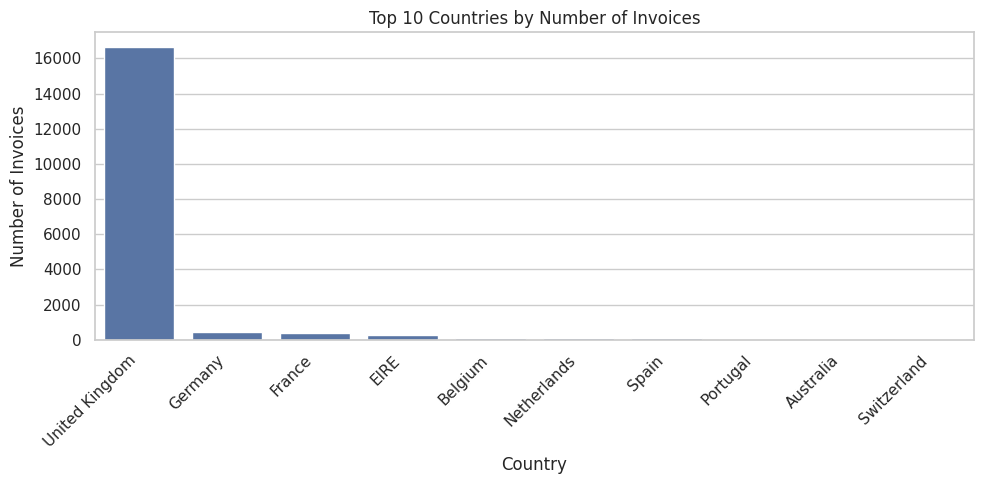

In [ ]:
# Number of unique invoices per country
country_volume = (
    df_clean.groupby("Country")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

print("Transaction volume by country (top 10):")
print(country_volume.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(
    x=country_volume.head(10).index,
    y=country_volume.head(10).values
)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Countries by Number of Invoices")
plt.ylabel("Number of Invoices")
plt.xlabel("Country")
plt.tight_layout()
plt.show()


###3.2 Identify top-selling products


Top 10 best-selling products (by quantity):
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


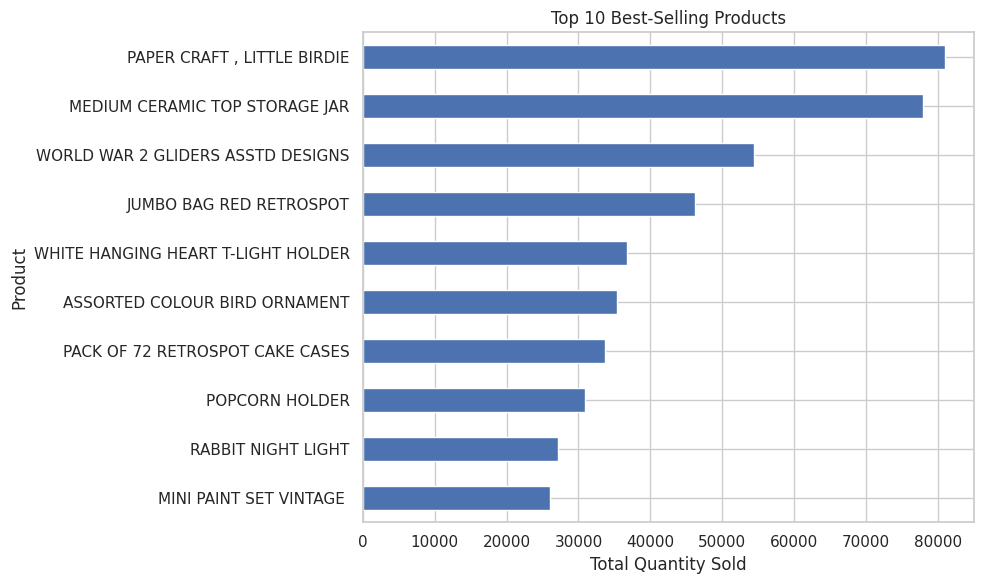

In [ ]:
# Total quantity sold per product
product_sales = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop 10 best-selling products (by quantity):")
print(product_sales.head(10))

plt.figure(figsize=(10, 6))
product_sales.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


### 3.3 Visualize purchase trends over time (monthly & daily invoices)

/tmp/ipython-input-3056391566.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_tx = df_ts["InvoiceNo"].resample("M").nunique()


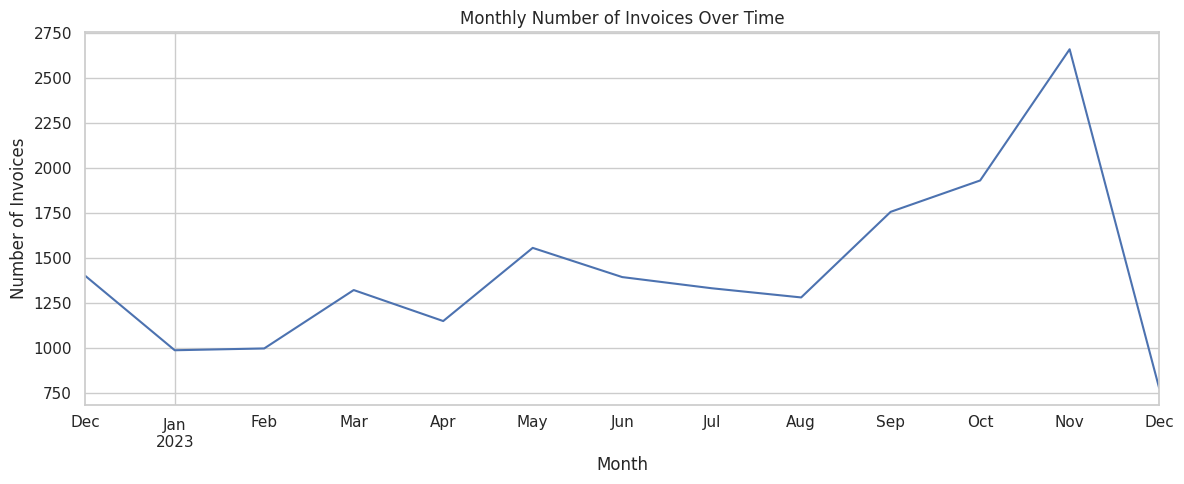

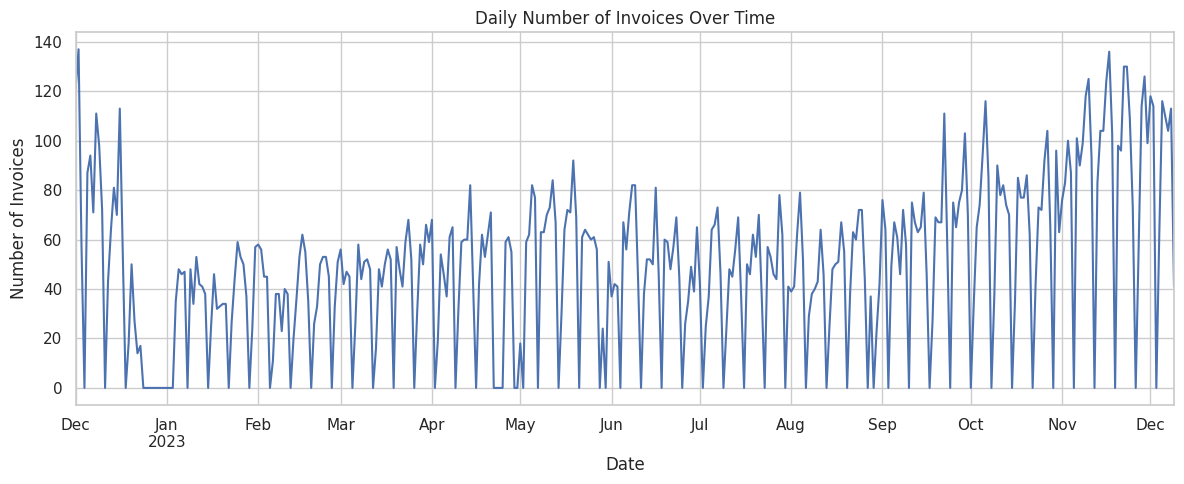

In [ ]:
# Set InvoiceDate as index for resampling
df_ts = df_clean.set_index("InvoiceDate").sort_index()

# Monthly transaction volume
monthly_tx = df_ts["InvoiceNo"].resample("M").nunique()

plt.figure(figsize=(12, 5))
monthly_tx.plot()
plt.title("Monthly Number of Invoices Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Invoices")
plt.tight_layout()
plt.show()

daily_tx = df_ts["InvoiceNo"].resample("D").nunique()

plt.figure(figsize=(12, 5))
daily_tx.plot()
plt.title("Daily Number of Invoices Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Invoices")
plt.tight_layout()
plt.show()



###3.4 Monetary distribution per transaction and per customer

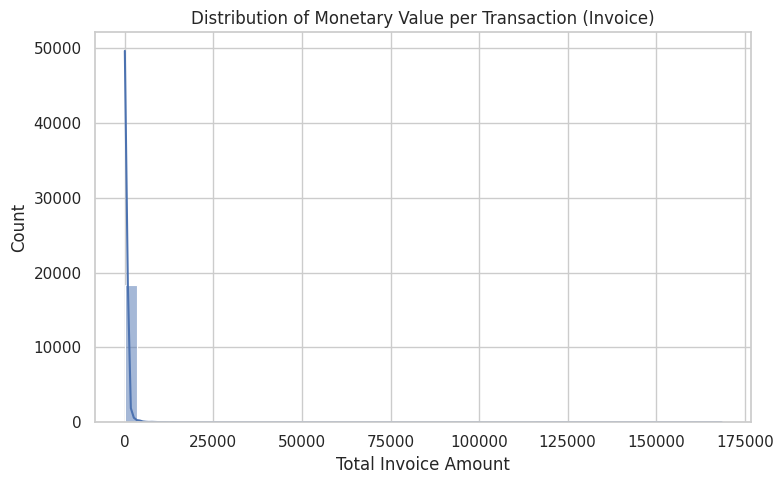

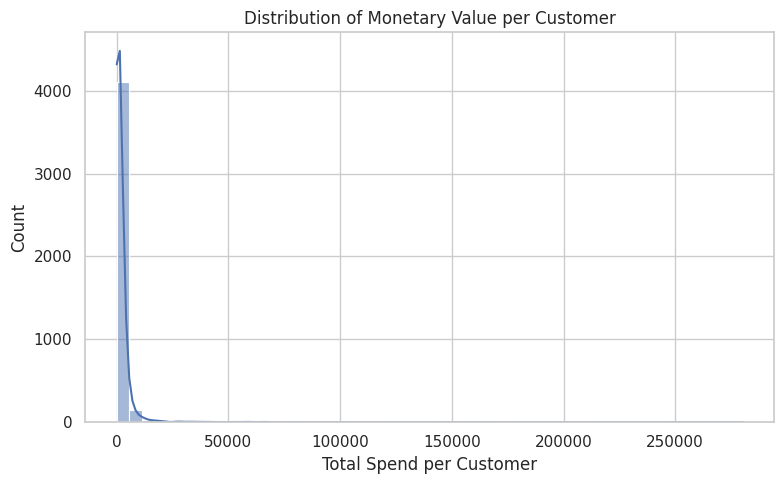

In [ ]:
# Total amount per line item
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Monetary per TRANSACTION (InvoiceNo)
invoice_monetary = df_clean.groupby("InvoiceNo")["TotalPrice"].sum()

plt.figure(figsize=(8, 5))
sns.histplot(invoice_monetary, bins=50, kde=True)
plt.title("Distribution of Monetary Value per Transaction (Invoice)")
plt.xlabel("Total Invoice Amount")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Monetary per CUSTOMER
customer_monetary = df_clean.groupby("CustomerID")["TotalPrice"].sum()

plt.figure(figsize=(8, 5))
sns.histplot(customer_monetary, bins=50, kde=True)
plt.title("Distribution of Monetary Value per Customer")
plt.xlabel("Total Spend per Customer")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


###3.5 RFM feature creation & distributions


RFM head:
            Recency  Frequency  Monetary
CustomerID                              
12346           326          1  77183.60
12347             2          7   4310.00
12348            75          4   1797.24
12349            19          1   1757.55
12350           310          1    334.40


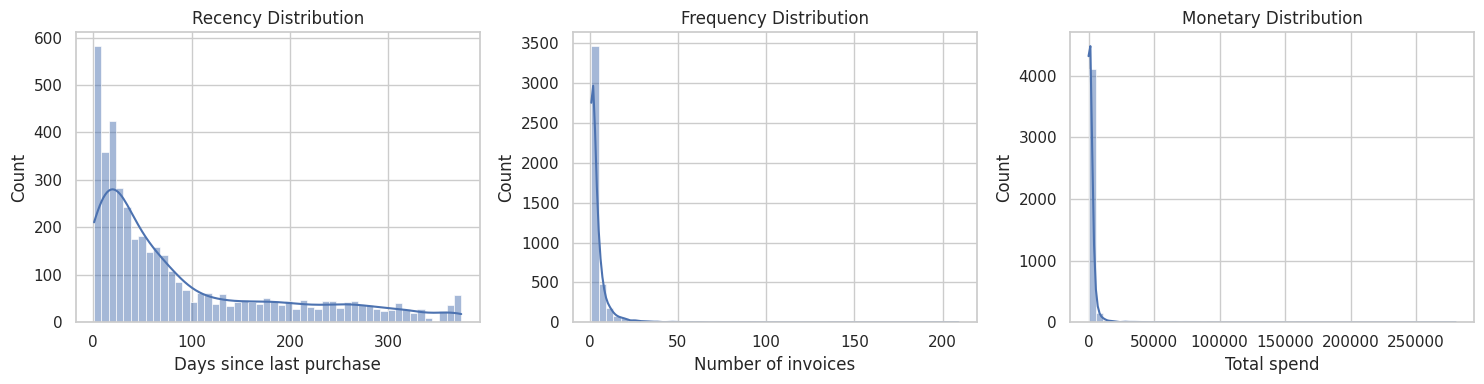

In [ ]:
# Snapshot date = one day after the last invoice date
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df_clean
    .groupby("CustomerID")
    .agg({
        "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
        "InvoiceNo": "nunique",                                   # Frequency
        "TotalPrice": "sum"                                       # Monetary
    })
    .rename(columns={
        "InvoiceDate": "Recency",
        "InvoiceNo": "Frequency",
        "TotalPrice": "Monetary"
    })
)

print("\nRFM head:")
print(rfm.head())

# RFM Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm["Recency"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days since last purchase")

sns.histplot(rfm["Frequency"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of invoices")

sns.histplot(rfm["Monetary"], bins=50, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total spend")

plt.tight_layout()
plt.show()


## Step 4 – Clustering Techniques & Model Evaluation

Now cluster customers based on RFM values using three algorithms:
- KMeans
- Agglomerative (hierarchical) clustering
- Gaussian Mixture Model (GMM)

I have
1. Standardize RFM features.
2. Use Elbow method (KMeans) to see a reasonable k range.
3. Plot Silhouette vs k for all three algorithms.
4. Compare Silhouette at k = 4 for all models.
5. Examine cluster profiles and scatter plots.
6. Choose a final model (e.g., KMeans k=4) and create
   business segments: High-Value, Regular, Occasional, At-Risk.


# 4.1 Standardize RFM (scaler, rfm_scaled)

In [ ]:
features = ["Recency", "Frequency", "Monetary"]

### 4.1 Standardize RFM

In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])

### 4.2 Elbow Method for KMeans(inertia vs k for KMeans)


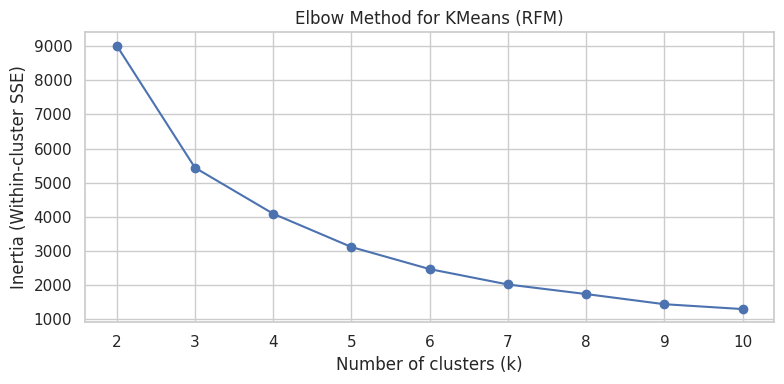

In [ ]:
K_range = range(2, 11)   # k = 2..10
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method for KMeans (RFM)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()




### 4.3 Silhouette vs k for KMeans, Agglomerative, GMM


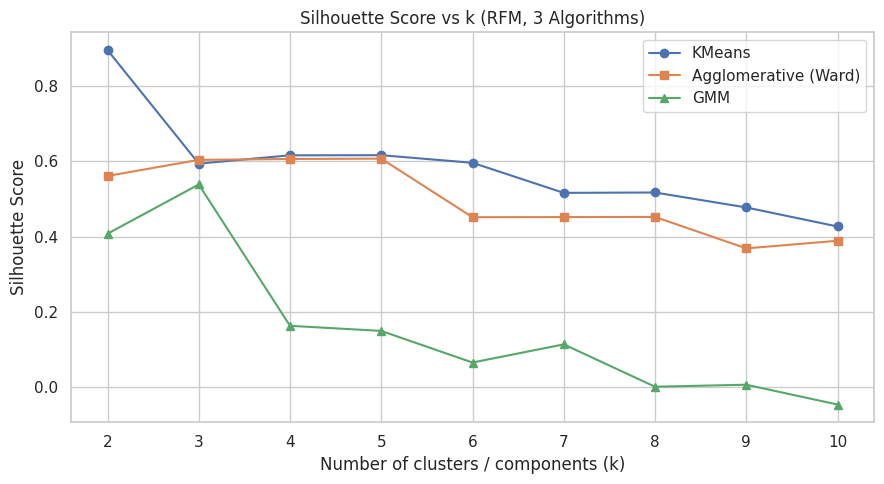

In [ ]:
K_range = range(2, 11)   # k = 2..10
sil_scores_kmeans = []
sil_scores_agg    = []
sil_scores_gmm    = []

for k in K_range:
    # --- KMeans ---
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = km.fit_predict(rfm_scaled)
    sil_km = silhouette_score(rfm_scaled, labels_km)
    sil_scores_kmeans.append(sil_km)

    # --- Agglomerative (Ward) ---
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels_agg = agg.fit_predict(rfm_scaled)
    sil_agg = silhouette_score(rfm_scaled, labels_agg)
    sil_scores_agg.append(sil_agg)

    # --- Gaussian Mixture ---
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels_gmm = gmm.fit_predict(rfm_scaled)
    sil_gmm = silhouette_score(rfm_scaled, labels_gmm)
    sil_scores_gmm.append(sil_gmm)

# Plot Silhouette vs k for all three
plt.figure(figsize=(9, 5))
plt.plot(K_range, sil_scores_kmeans, marker="o", label="KMeans")
plt.plot(K_range, sil_scores_agg,    marker="s", label="Agglomerative (Ward)")
plt.plot(K_range, sil_scores_gmm,    marker="^", label="GMM")
plt.title("Silhouette Score vs k (RFM, 3 Algorithms)")
plt.xlabel("Number of clusters / components (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(K_range))
plt.legend()
plt.tight_layout()
plt.show()


### 4.4 Best k per algorithm(from Silhouette curve)

In [ ]:
K_list = np.array(list(K_range))

best_k_kmeans = K_list[np.argmax(sil_scores_kmeans)]
best_k_agg    = K_list[np.argmax(sil_scores_agg)]
best_k_gmm    = K_list[np.argmax(sil_scores_gmm)]

print("Best k by Silhouette:")
print(f"  KMeans          : k = {best_k_kmeans}, Silhouette = {max(sil_scores_kmeans):.4f}")
print(f"  Agglomerative   : k = {best_k_agg},  Silhouette = {max(sil_scores_agg):.4f}")
print(f"  Gaussian Mixture: k = {best_k_gmm},  Silhouette = {max(sil_scores_gmm):.4f}")


Best k by Silhouette:
  KMeans          : k = 2, Silhouette = 0.8958
  Agglomerative   : k = 5,  Silhouette = 0.6073
  Gaussian Mixture: k = 3,  Silhouette = 0.5387


###  4.5 Fit 3 models at a common k (k = 4) and compare Silhouette

We now fix k = 4 for all three algorithms to get four customer
segments and compare their Silhouette scores directly.



Silhouette scores at k = 4:


,model,silhouette
0,KMeans (k=4),0.616213
1,"Agglomerative (k=4, ward)",0.606533
2,Gaussian Mixture (4 components),0.163302


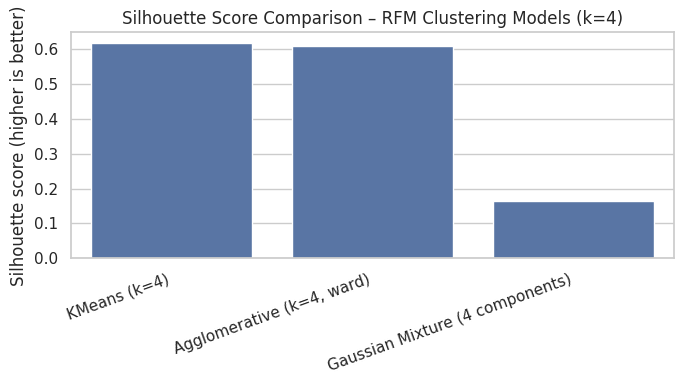

In [ ]:
k_fixed = 4
models = {}

# KMeans
kmeans = KMeans(n_clusters=k_fixed, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(rfm_scaled)
models["kmeans"] = {
    "name": f"KMeans (k={k_fixed})",
    "labels": labels_kmeans,
    "estimator": kmeans
}

# Agglomerative
agg = AgglomerativeClustering(n_clusters=k_fixed, linkage="ward")
labels_agg = agg.fit_predict(rfm_scaled)
models["agg"] = {
    "name": f"Agglomerative (k={k_fixed}, ward)",
    "labels": labels_agg,
    "estimator": agg
}

# GMM
gmm = GaussianMixture(n_components=k_fixed, random_state=42)
labels_gmm = gmm.fit_predict(rfm_scaled)
models["gmm"] = {
    "name": f"Gaussian Mixture ({k_fixed} components)",
    "labels": labels_gmm,
    "estimator": gmm
}

# Silhouette comparison at k_fixed
results = []
for key, m in models.items():
    sil = silhouette_score(rfm_scaled, m["labels"])
    results.append({"model": m["name"], "silhouette": sil})

results_df = pd.DataFrame(results)
print("\nSilhouette scores at k = 4:")
display(results_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=results_df, x="model", y="silhouette")
plt.title("Silhouette Score Comparison – RFM Clustering Models (k=4)")
plt.ylabel("Silhouette score (higher is better)")
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### 4.6 Cluster profiles for each model (mean R, F, M)

We now inspect the mean RFM values per cluster for each algorithm.
This shows what kind of customers are in each segment and helps us
judge business interpretability.



=== KMeans (k=4) – cluster profile (mean RFM) ===


,Recency,Frequency,Monetary
cluster_kmeans,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


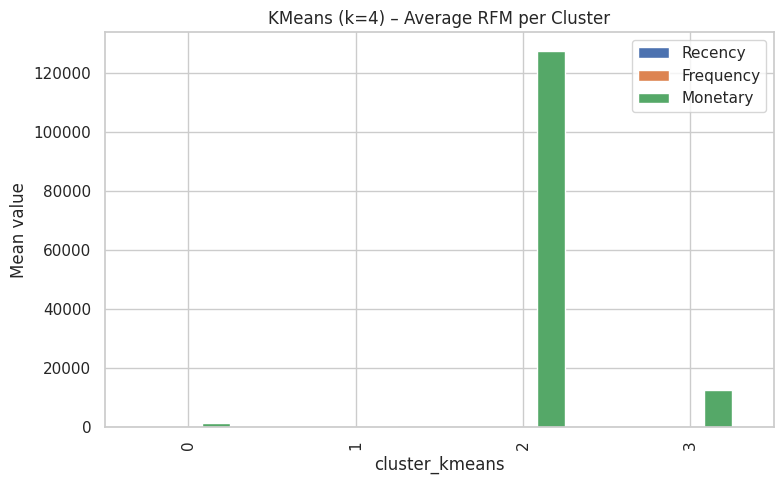


=== Agglomerative (k=4, ward) – cluster profile (mean RFM) ===


,Recency,Frequency,Monetary
cluster_agg,,,
0,24.928571,43.785714,31348.385536
1,11.000000,43.875000,164658.498750
2,46.205414,4.305263,1625.457204
3,259.542677,1.489989,457.307820


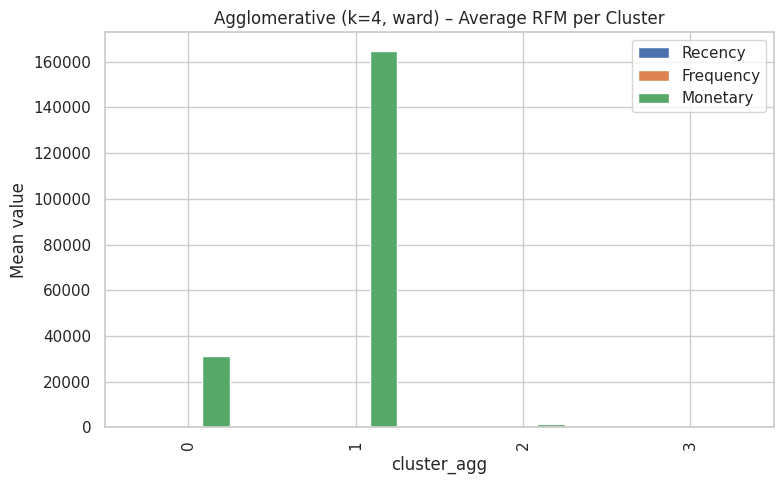


=== Gaussian Mixture (4 components) – cluster profile (mean RFM) ===


,Recency,Frequency,Monetary
cluster_gmm,,,
0,33.502154,4.756308,1613.613897
1,142.441504,1.403900,354.993877
2,6.050633,41.240506,39010.975823
3,82.677083,9.418750,5089.086294


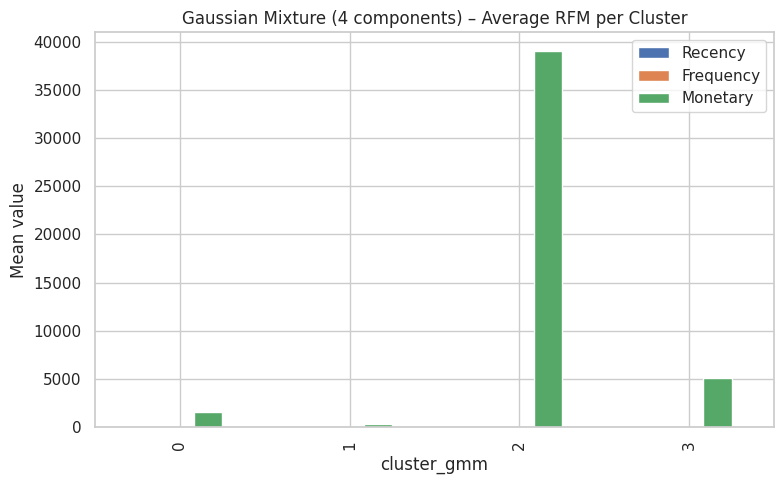

In [ ]:
# Add cluster labels to rfm for each model and plot profiles
for key, m in models.items():
    cluster_col = f"cluster_{key}"
    rfm[cluster_col] = m["labels"]

    cluster_profile = rfm.groupby(cluster_col)[features].mean()
    print(f"\n=== {m['name']} – cluster profile (mean RFM) ===")
    display(cluster_profile)

    # Bar chart of R/F/M per cluster
    cluster_profile.plot(kind="bar", figsize=(8, 5))
    plt.title(f"{m['name']} – Average RFM per Cluster")
    plt.ylabel("Mean value")
    plt.tight_layout()
    plt.show()

### 4.7 Scatter plots (Recency vs Monetary ) for each model

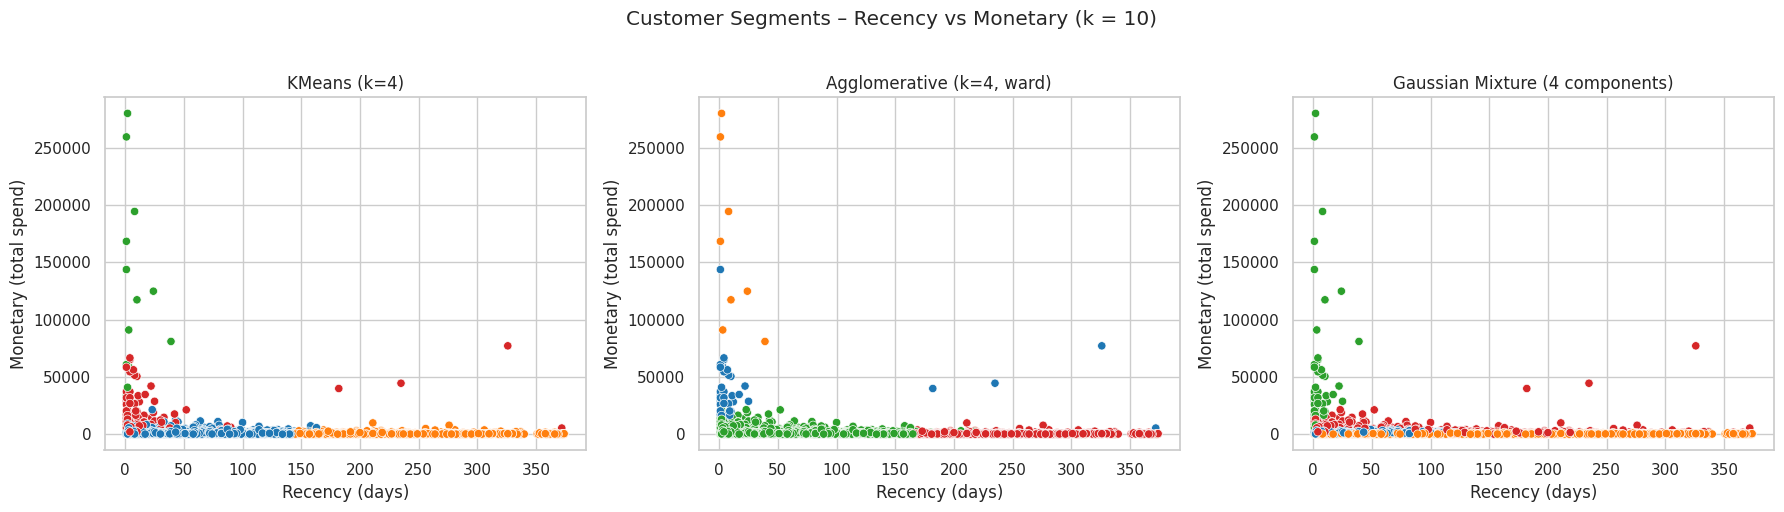

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (key, m) in zip(axes, models.items()):
    cluster_col = f"cluster_{key}"
    sns.scatterplot(
        data=rfm,
        x="Recency",
        y="Monetary",
        hue=cluster_col,
        palette="tab10",
        ax=ax,
        legend=False
    )
    ax.set_title(m["name"])
    ax.set_xlabel("Recency (days)")
    ax.set_ylabel("Monetary (total spend)")

plt.suptitle(f"Customer Segments – Recency vs Monetary (k = {k})", y=1.02)
plt.tight_layout()
plt.show()


## 4.8 Select final model (e.g., KMeans k=4) and create business segments

From the Silhouette scores and RFM profiles, I pick the model that
offers both good separation and interpretable segments.
Here KMeans (k=4) is selected as the final model.

I then:
- Assign Cluster labels from the chosen model.
- Compute a value_score per cluster (low Recency, high F & M = good).
- Rank clusters and map them to business-friendly labels:
  [High-Value, Regular, Occasional, At-Risk].
- Visualize the final segments in 2D and 3D.


In [ ]:
best_key = "kmeans"   # change to "agg" or "gmm" if you decide differently
best_model = models[best_key]["estimator"]
best_labels = models[best_key]["labels"]

# Final cluster assignment
rfm["Cluster"] = best_labels

# Metrics for report
inertia = best_model.inertia_ if hasattr(best_model, "inertia_") else None
sil_final = silhouette_score(rfm_scaled, rfm["Cluster"])

print(f"\nFinal model: {models[best_key]['name']}")
if inertia is not None:
    print(f"Inertia: {inertia:.2f}")
print(f"Silhouette score: {sil_final:.4f}")

# Cluster profile and value_score
cluster_profile = rfm.groupby("Cluster")[features].mean()
print("\nFinal cluster profile (mean R, F, M):")
display(cluster_profile)

profile_std = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()

value_score = (
    -profile_std["Recency"] +  # lower Recency is better
     profile_std["Frequency"] +
     profile_std["Monetary"]
)

print("\nCluster value scores:")
print(value_score)

sorted_clusters = value_score.sort_values(ascending=False).index.tolist()
segment_names = ["High-Value", "Regular", "Occasional", "At-Risk"]
segment_map = {cluster_id: segment_names[i] for i, cluster_id in enumerate(sorted_clusters)}

print("\nCluster -> Segment mapping:")
print(segment_map)

rfm["Segment"] = rfm["Cluster"].map(segment_map)
print("\nSegment counts:")
print(rfm["Segment"].value_counts())


Final model: KMeans (k=4)
Inertia: 4092.14
Silhouette score: 0.6162

Final cluster profile (mean R, F, M):


,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490



Cluster value scores:
Cluster
0   -0.878091
1   -2.741307
2    3.572720
3    0.046678
dtype: float64

Cluster -> Segment mapping:
{2: 'High-Value', 3: 'Regular', 0: 'Occasional', 1: 'At-Risk'}

Segment counts:
Segment
Occasional    3054
At-Risk       1067
Regular        204
High-Value      13
Name: count, dtype: int64


### 4.9 Visualize final segments (2D & 3D)

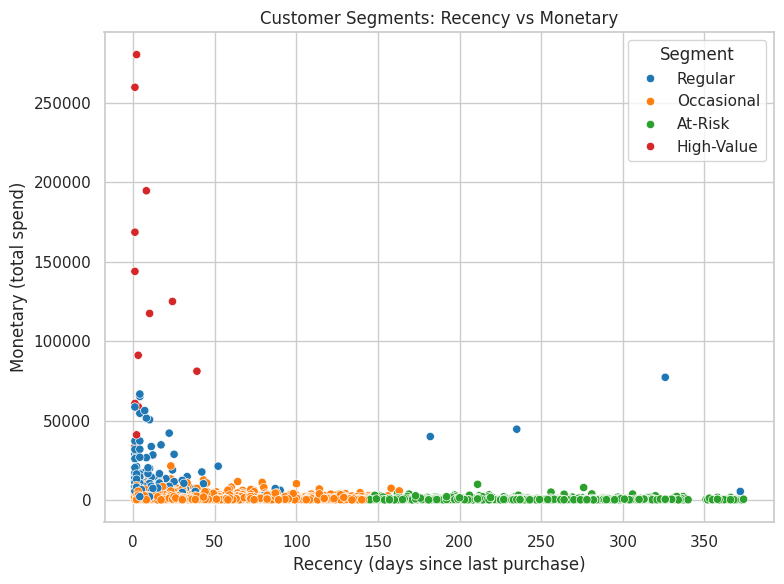

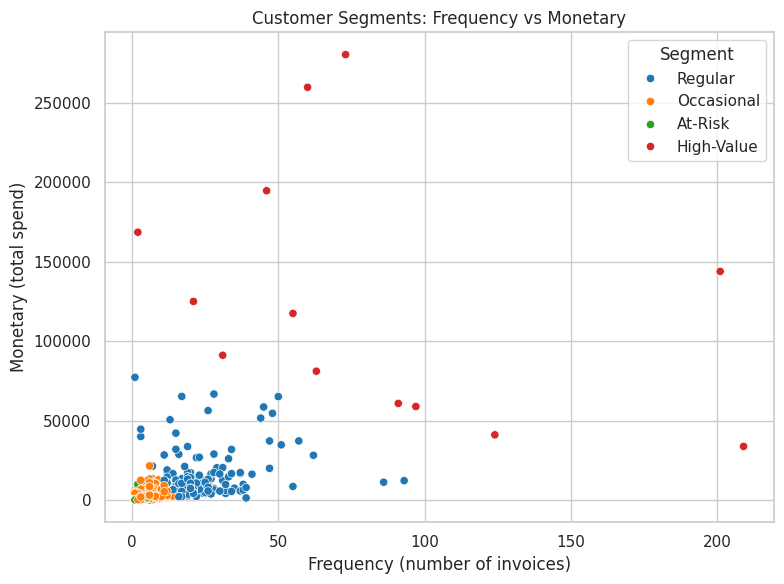

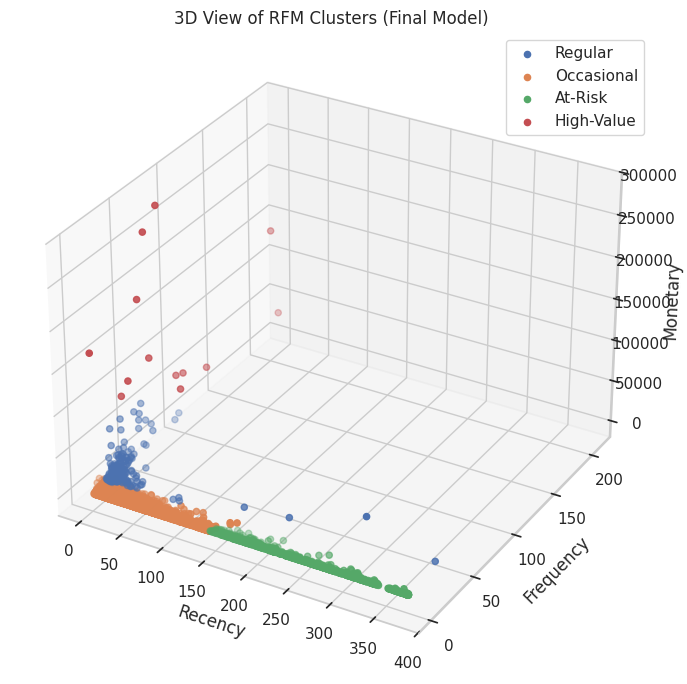

In [ ]:
rfm_plot = rfm.reset_index()  # CustomerID as column

# Recency vs Monetary
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=rfm_plot,
    x="Recency",
    y="Monetary",
    hue="Segment",
    palette="tab10"
)
plt.xlabel("Recency (days since last purchase)")
plt.ylabel("Monetary (total spend)")
plt.title("Customer Segments: Recency vs Monetary")
plt.legend(title="Segment")
plt.tight_layout()
plt.show()

# Frequency vs Monetary
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=rfm_plot,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    palette="tab10"
)
plt.xlabel("Frequency (number of invoices)")
plt.ylabel("Monetary (total spend)")
plt.title("Customer Segments: Frequency vs Monetary")
plt.legend(title="Segment")
plt.tight_layout()
plt.show()

# 3D scatter
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for seg in rfm_plot["Segment"].unique():
    subset = rfm_plot[rfm_plot["Segment"] == seg]
    ax.scatter(
        subset["Recency"],
        subset["Frequency"],
        subset["Monetary"],
        label=seg
    )

ax.set_title("3D View of RFM Clusters (Final Model)")
ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")
ax.legend()
plt.tight_layout()
plt.show()


## Step 5 – Collaborative Filtering Recommendation System

We now build a simple item–item collaborative filtering model:
- Create a CustomerID × Product (Description) matrix of quantities.
- Compute cosine similarity between products.
- Visualize a similarity heatmap for top-selling items.
- Define a function to recommend similar products based on a
  chosen item.


### 5.1 Build customer_product matrix.

In [ ]:
customer_product = df_clean.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

### 5.2 Compute item_sim_df (cosine similarity)

In [ ]:
item_similarity = cosine_similarity(customer_product.T)
item_sim_df = pd.DataFrame(
    item_similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)
print("\nItem–Item similarity matrix shape:", item_sim_df.shape)


Item–Item similarity matrix shape: (3877, 3877)


### 5.3 Heatmap of similarity for top 20 products

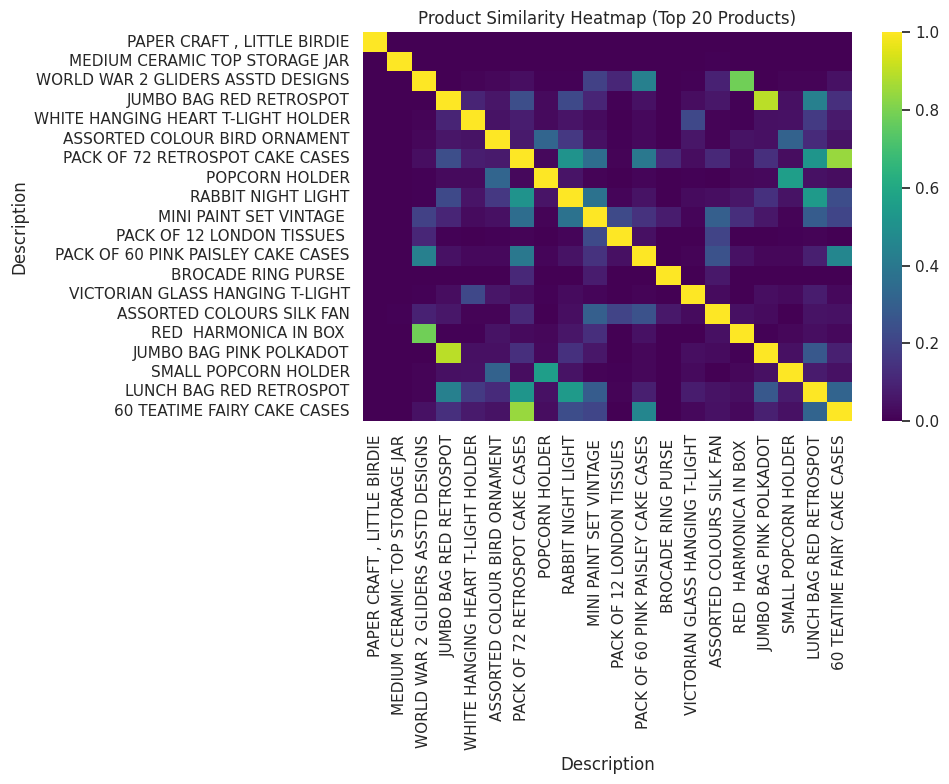

In [ ]:
top_products = product_sales.head(20).index  # from Step 3.2
sim_subset = item_sim_df.loc[top_products, top_products]

plt.figure(figsize=(10, 8))
sns.heatmap(sim_subset, cmap="viridis")
plt.title("Product Similarity Heatmap (Top 20 Products)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 5.4 Simple recommendation function

In [ ]:
def recommend_similar_products(product_name, similarity_df, top_n=5):
    if product_name not in similarity_df.index:
        print("Product not found in similarity matrix.")
        return []
    scores = similarity_df.loc[product_name].sort_values(ascending=False)
    return scores.iloc[1:top_n+1].index.tolist()  # skip itself

example_product = "WHITE HANGING HEART T-LIGHT HOLDER"
print(f"\nSimilar products to '{example_product}':")
print(recommend_similar_products(example_product, item_sim_df, top_n=5))



Similar products to 'WHITE HANGING HEART T-LIGHT HOLDER':
['GIN + TONIC DIET METAL SIGN', 'RED HANGING HEART T-LIGHT HOLDER', 'WASHROOM METAL SIGN', 'LAUNDRY 15C METAL SIGN', 'GREEN VINTAGE SPOT BEAKER']


## Step 6 – Save Models For Streamlit App

Finally, I save:
- The RFM clustering model (scaler + final clustering estimator +
  feature list + segment label mapping) as rfm_kmeans_segment_model.pkl
- The product similarity matrix for recommendations as
  product_similarity_model.pkl

The Streamlit app can load these objects to:
- Predict customer segment from R, F, M values.
- Recommend similar products for a selected item.

In [ ]:
rfm_model = {
    "scaler": scaler,               # StandardScaler fitted on RFM
    "model": best_model,            # Final clustering model (e.g., KMeans k=4)
    "features": features,           # ["Recency", "Frequency", "Monetary"]
    "segment_map": segment_map      # cluster_id -> segment label
}

rfm_model_path = "/content/drive/MyDrive/Labmentix_P2/rfm_kmeans_segment_model.pkl"
joblib.dump(rfm_model, rfm_model_path)
print(f"Saved RFM clustering model to: {rfm_model_path}")

product_sim_path = "/content/drive/MyDrive/Labmentix_P2/product_similarity_model.pkl"
joblib.dump(item_sim_df, product_sim_path)
print(f"Saved product similarity model to: {product_sim_path}")


Saved RFM clustering model to: /content/drive/MyDrive/Labmentix_P2/rfm_kmeans_segment_model.pkl
Saved product similarity model to: /content/drive/MyDrive/Labmentix_P2/product_similarity_model.pkl


In [ ]:
!pip install nbconvert
!jupyter nbconvert --to html "/content/drive/MyDrive/Labmentix_P2/Shoppers_Spectrum.ipynb"


[NbConvertApp] Converting notebook /content/drive/MyDrive/Labmentix_P2/Shoppers_Spectrum.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 17 image(s).
[NbConvertApp] Writing 1749247 bytes to /content/drive/MyDrive/Labmentix_P2/Shoppers_Spectrum.html
